# Fake News Detection Using Natural Language Processing (NLP)

## Introduction

This notebook presents the implementation of a Fake News Detection system using Natural Language Processing (NLP), Machine Learning, and Deep Learning. The objective is to classify news articles as **Fake** or **Real** by applying text preprocessing, feature extraction, machine learning, and deep learning techniques.

### Objectives
- Load and combine the Fake and True news datasets.
- Clean and preprocess the text data using NLP techniques.
- Perform Exploratory Data Analysis (EDA).
- Extract text features using TF-IDF.
- Train and evaluate a Random Forest model.
- Build and evaluate a GRU deep learning model.
- Compare the performance of both models.

### Workflow
1. Import Required Libraries
2. Dataset Collection
3. Dataset Exploration
4. Dataset Merging and Labeling
5. Text Cleaning
6. Save Cleaned Dataset
7. Text Preprocessing
8. Exploratory Data Analysis (EDA)
9. Train-Test Split
10. TF-IDF Feature Extraction
11. Random Forest Model
12. Random Forest Evaluation
13. GRU Model
14. GRU Training
15. GRU Evaluation
16. Model Comparison


# 1. Import Required Libraries

In [1]:
import pandas as pd
import string
import re
import nltk
import matplotlib.pyplot as plt

from nltk.tokenize import wordpunct_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dense
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# 2. Dataset Collection

In [2]:
fake = pd.read_csv("../data/Fake.csv")
true = pd.read_csv("../data/True.csv")

In [3]:
print("Fake news:", len(fake))
print("True news:", len(true))
print("Total:", len(fake) + len(true))

Fake news: 23481
True news: 21417
Total: 44898


# 3. Dataset Exploration

In [4]:
fake.head()

true.head()

print(fake.shape)

print(true.shape)

(23481, 4)
(21417, 4)


# 4. Dataset Merging and Labeling

In [5]:
fake["label"] = 0
true["label"] = 1

df = pd.concat([fake, true], ignore_index=True)

df = df.sample(frac=1, random_state=42).reset_index(drop=True)

df.head()

print(df.shape)

(44898, 5)


# 5. Text Cleaning

In [6]:
df["text"] = df["text"].str.lower()

df["text"] = df["text"].str.translate(
    str.maketrans("", "", string.punctuation)
)

df["text"] = df["text"].apply(
    lambda x: re.sub(r"\d+", "", x)
)

df["text"] = df["text"].str.strip()

df.head()

,title,text,subject,date,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,st century wire says ben stein reputable profe...,US_News,"February 13, 2017",0
1,Trump drops Steve Bannon from National Securit...,washington reuters us president donald trump ...,politicsNews,"April 5, 2017",1
2,Puerto Rico expects U.S. to lift Jones Act shi...,reuters puerto rico governor ricardo rossello...,politicsNews,"September 27, 2017",1
3,OOPS: Trump Just Accidentally Confirmed He Le...,on monday donald trump once again embarrassed ...,News,"May 22, 2017",0
4,Donald Trump heads for Scotland to reopen a go...,glasgow scotland reuters most us presidential...,politicsNews,"June 24, 2016",1


In [7]:
print("Dataset shape after cleaning:", df.shape)
print("Rows after cleaning:", len(df))

Dataset shape after cleaning: (44898, 5)
Rows after cleaning: 44898


# 6. Save Cleaned Dataset

In [8]:
df.to_csv("../data/processed/clean_news.csv", index=False)

In [9]:
print("Fake news:", len(fake))
print("True news:", len(true))
print("Total:", len(fake) + len(true))

Fake news: 23481
True news: 21417
Total: 44898


# 7. Text Preprocessing

In [10]:
nltk.download("stopwords")
nltk.download("punkt")
nltk.download("wordnet")
nltk.download("omw-1.4")

stop_words = set(stopwords.words("english"))

lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    tokens = wordpunct_tokenize(text)
    tokens = [word for word in tokens if word.isalpha()]
    tokens = [word for word in tokens if word not in stop_words]
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    return " ".join(tokens)

df["Clean_Text"] = df["text"].apply(preprocess_text)

df[["text", "Clean_Text"]].head()

[nltk_data] Error loading stopwords: <urlopen error pathsec.urlopen:
[nltk_data]     no validated address for host
[nltk_data]     'raw.githubusercontent.com'; refusing to connect by
[nltk_data]     unvalidated hostname>
[nltk_data] Error loading punkt: <urlopen error pathsec.urlopen: no
[nltk_data]     validated address for host
[nltk_data]     'raw.githubusercontent.com'; refusing to connect by
[nltk_data]     unvalidated hostname>
[nltk_data] Error loading wordnet: <urlopen error pathsec.urlopen: no
[nltk_data]     validated address for host
[nltk_data]     'raw.githubusercontent.com'; refusing to connect by
[nltk_data]     unvalidated hostname>
[nltk_data] Error loading omw-1.4: <urlopen error pathsec.urlopen: no
[nltk_data]     validated address for host
[nltk_data]     'raw.githubusercontent.com'; refusing to connect by
[nltk_data]     unvalidated hostname>


,text,Clean_Text
0,st century wire says ben stein reputable profe...,st century wire say ben stein reputable profes...
1,washington reuters us president donald trump ...,washington reuters u president donald trump re...
2,reuters puerto rico governor ricardo rossello...,reuters puerto rico governor ricardo rossello ...
3,on monday donald trump once again embarrassed ...,monday donald trump embarrassed country accide...
4,glasgow scotland reuters most us presidential...,glasgow scotland reuters u presidential candid...


# 8. Exploratory Data Analysis (EDA)

Dataset Shape: (44898, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   title       44898 non-null  object
 1   text        44898 non-null  object
 2   subject     44898 non-null  object
 3   date        44898 non-null  object
 4   label       44898 non-null  int64 
 5   Clean_Text  44898 non-null  object
dtypes: int64(1), object(5)
memory usage: 2.1+ MB
title         0
text          0
subject       0
date          0
label         0
Clean_Text    0
dtype: int64
label
0    23481
1    21417
Name: count, dtype: int64


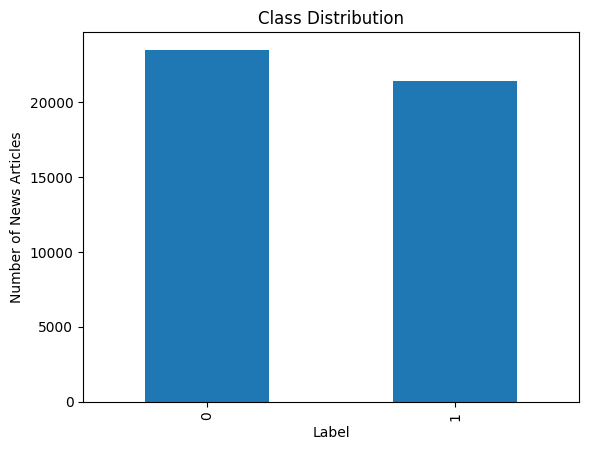

In [11]:
print("Dataset Shape:", df.shape)

df.info()

print(df.isnull().sum())

print(df["label"].value_counts())

df["label"].value_counts().plot(kind="bar")

plt.title("Class Distribution")
plt.xlabel("Label")
plt.ylabel("Number of News Articles")

plt.show()

# 9. Train-Test Split

In [12]:
X_train_text, X_test_text, y_train, y_test = train_test_split(
    df["Clean_Text"],
    df["label"],
    test_size=0.2,
    random_state=42
)

In [13]:
print("Total samples:", len(df))
print("Training samples:", len(y_train))
print("Testing samples:", len(y_test))

print("Training percentage:", len(y_train) / len(df) * 100)
print("Testing percentage:", len(y_test) / len(df) * 100)

Total samples: 44898
Training samples: 35918
Testing samples: 8980
Training percentage: 79.999109091719
Testing percentage: 20.000890908280994


# 10. TF-IDF Feature Extraction

In [14]:
tfidf = TfidfVectorizer(max_features=5000)

X_train = tfidf.fit_transform(X_train_text)
X_test = tfidf.transform(X_test_text)

# 11. Random Forest Model

In [15]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

# 12. Random Forest Evaluation

In [16]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Accuracy:", rf_accuracy)

print(classification_report(y_test, y_pred_rf))

cm_rf = confusion_matrix(y_test, y_pred_rf)

print(cm_rf)

Accuracy: 0.9964365256124722
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4710
           1       1.00      1.00      1.00      4270

    accuracy                           1.00      8980
   macro avg       1.00      1.00      1.00      8980
weighted avg       1.00      1.00      1.00      8980

[[4695   15]
 [  17 4253]]


# 13. GRU Model

In [17]:
tokenizer = Tokenizer(num_words=5000)

tokenizer.fit_on_texts(X_train_text)

X_train_seq = tokenizer.texts_to_sequences(X_train_text)
X_test_seq = tokenizer.texts_to_sequences(X_test_text)

X_train_dl = pad_sequences(X_train_seq, maxlen=200)
X_test_dl = pad_sequences(X_test_seq, maxlen=200)

y_train_dl = y_train
y_test_dl = y_test

model = Sequential()

model.add(
    Embedding(
        input_dim=5000,
        output_dim=128,
        input_length=200
    )
)

model.add(GRU(64))

model.add(Dense(1, activation="sigmoid"))

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

c:\Users\sahan\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

# 14. GRU Training

In [18]:
history = model.fit(
    X_train_dl,
    y_train_dl,
    epochs=5,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

Epoch 1/5
449/449 ━━━━━━━━━━━━━━━━━━━━ 60s 128ms/step - accuracy: 0.9367 - loss: 0.1546 - val_accuracy: 0.9609 - val_loss: 0.1092
Epoch 2/5
449/449 ━━━━━━━━━━━━━━━━━━━━ 58s 128ms/step - accuracy: 0.9762 - loss: 0.0705 - val_accuracy: 0.9823 - val_loss: 0.0580
Epoch 3/5
449/449 ━━━━━━━━━━━━━━━━━━━━ 57s 127ms/step - accuracy: 0.9869 - loss: 0.0428 - val_accuracy: 0.9854 - val_loss: 0.0485
Epoch 4/5
449/449 ━━━━━━━━━━━━━━━━━━━━ 57s 127ms/step - accuracy: 0.9893 - loss: 0.0355 - val_accuracy: 0.9832 - val_loss: 0.0560
Epoch 5/5
449/449 ━━━━━━━━━━━━━━━━━━━━ 73s 162ms/step - accuracy: 0.9918 - loss: 0.0271 - val_accuracy: 0.9918 - val_loss: 0.0295


# 15. GRU Evaluation

In [19]:
loss, gru_accuracy = model.evaluate(
    X_test_dl,
    y_test_dl
)

print("Test Accuracy:", gru_accuracy)

y_pred_prob = model.predict(X_test_dl)

y_pred_gru = (y_pred_prob > 0.5).astype(int)

print(classification_report(y_test_dl, y_pred_gru))

cm_gru = confusion_matrix(y_test_dl, y_pred_gru)

print(cm_gru)

281/281 ━━━━━━━━━━━━━━━━━━━━ 12s 43ms/step - accuracy: 0.9890 - loss: 0.0401
Test Accuracy: 0.9889755249023438
281/281 ━━━━━━━━━━━━━━━━━━━━ 13s 43ms/step
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4710
           1       0.99      0.99      0.99      4270

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980

[[4650   60]
 [  39 4231]]


# 16. Model Comparison

In [20]:
comparison = {
    "Model": ["Random Forest", "GRU"],
    "Accuracy": [rf_accuracy, gru_accuracy]
}

comparison_df = pd.DataFrame(comparison)

comparison_df

,Model,Accuracy
0,Random Forest,0.996437
1,GRU,0.988976


In [27]:
comparison = pd.DataFrame({
    "Model": ["Random Forest", "GRU"],
    
    "Accuracy": [
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test_dl, y_pred_gru)
    ],
    "Precision": [
        precision_score(y_test, y_pred_rf),
        precision_score(y_test_dl, y_pred_gru)
    ],
    "Recall": [
        recall_score(y_test, y_pred_rf),
        recall_score(y_test_dl, y_pred_gru)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_rf),
        f1_score(y_test_dl, y_pred_gru)
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest,0.996437,0.996485,0.996019,0.996252
1,GRU,0.988976,0.986017,0.990867,0.988436
